In [1]:
import sys
sys.path.insert(0, "/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2025_Speckle_Flow_Networks_QIP/coded_wfs_sim")

from coded_wfs_sim import geometry
from coded_wfs_sim import propagator
from coded_wfs_sim import visualization
from coded_wfs_sim import utils

import numpy as np
from tifffile import tifffile
from matplotlib import pyplot as plt
import cv2

import torch
from torch import nn, Tensor
from torchvision.models.optical_flow import raft_large
from torchvision.models.optical_flow import Raft_Large_Weights
import torchvision.transforms.functional as F
from torchvision.utils import flow_to_image
from torch.utils.tensorboard import SummaryWriter

from scipy.ndimage import gaussian_filter, median_filter
from scipy.signal import correlate2d, convolve2d, tukey
from scipy.interpolate import RegularGridInterpolator

from typing import Optional, Union

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


# Learning Pipeline

1. Test that everything works
2. Show what each step does
3. Use checkpoints to show inference

In [2]:
def generate_ref_obj_wavefields(RI_distribution, phase_mask, dist_m_im, dist_m_im_var,
                                wl, n_background, spatial_resolution, spatial_support, mag, padding=256, NA=1):

    k = 2*np.pi/wl
    output_field = propagator.propagate_beam_2(np.ones_like(RI_distribution[..., 1]), RI_distribution, n_background, wl, spatial_resolution)
    
    # prop to focal plane
    output_field = propagator.propagate(output_field, wl/n_background, spatial_resolution, spatial_support[2]/2, padding=padding, direction='backward')

    # NA based low-pass filtering
    # output_field = utils.low_pass_filter_NA(output_field, wl, spatial_resolution, NA)
    
    # prop back to mask plane from image plane (plus variation) ensures focus plane imaging
    output_field = propagator.propagate(output_field, wl, np.array(spatial_resolution)*mag, dist_m_im + dist_m_im_var, 
                                        padding=padding, direction='backward')
    output_field = gaussian_filter(output_field, np.random.rand() + 8.) # smoothing -> partial spatial coherence
    
    # ground truth flow
    flow_y, flow_x = utils.grad_optr(np.angle(output_field))
    gt_flow_y = (np.remainder(flow_y + np.pi, 2*np.pi) - np.pi)/(spatial_resolution[0]*mag)**2/k*(dist_m_im + dist_m_im_var)
    gt_flow_x = (np.remainder(flow_x + np.pi, 2*np.pi) - np.pi)/(spatial_resolution[1]*mag)**2/k*(dist_m_im + dist_m_im_var)
    
    # mask modulation and prop to image plane
    output_field = propagator.propagate(output_field*phase_mask, wl, np.array(spatial_resolution)*mag, dist_m_im + dist_m_im_var, 
                                        padding=padding, direction='forward')
    ref_field = propagator.propagate(phase_mask, wl, np.array(spatial_resolution)*mag, dist_m_im + dist_m_im_var, 
                                        padding=padding, direction='forward')
    
    return ref_field[5:-5, 5:-5], output_field[5:-5, 5:-5], [-1*gt_flow_x[5:-5, 5:-5], -1*gt_flow_y[5:-5, 5:-5]]


def create_phase_mask(height_range, grid_shape, tile_size, wl, RI_pm):
    h_pm = wl/np.random.randint(height_range[0], height_range[1])
    hmap_pm = geometry.initialize_hmap_uniform_sampling(grid_shape[:2], tile_size, h_pm)
    opd_pm = hmap_pm*RI_pm + (hmap_pm.max() - hmap_pm)*1. # phase mask in air
    
    return np.exp(1j*(2*np.pi/wl)*opd_pm)


# model
def init_model_RAFT(model, device='cuda', checkpoint=None):
    
    if checkpoint == None:
        print('Loading models with pretrained weights')
        weights = Raft_Large_Weights.DEFAULT.get_state_dict()
        weights['feature_encoder.convnormrelu.0.weight'] = torch.mean(weights['feature_encoder.convnormrelu.0.weight'], dim=1).unsqueeze(1)
        weights['context_encoder.convnormrelu.0.weight'] = torch.mean(weights['context_encoder.convnormrelu.0.weight'], dim=1).unsqueeze(1)
    else:
        print(f'Loading models with checkpoint: {checkpoint}')
        weights = torch.load(checkpoint, map_location=torch.device(device))
    
    # model = raft_large(progress=False)
    model.feature_encoder.convnormrelu[0] = torch.nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    model.context_encoder.convnormrelu[0] = torch.nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    
    model.load_state_dict(weights)
    
    return model.to(device)
    

def RAFT_loss(predictions, target, device='cuda'):
	loss_fn = torch.nn.L1Loss()
	N = len(predictions)
	
	w = torch.pow(torch.tensor(0.8), N-torch.tensor(range(1, N+1))).to(device)
	loss_n = torch.sum(torch.abs(torch.stack(predictions, dim=0) - target.unsqueeze(0).repeat(12, 1, 1, 1, 1)), dim=[1, 2, 3, 4])
	
	return torch.sum(w*loss_n).squeeze()


def plot(imgs, **imshow_kwargs):
    if not isinstance(imgs[0], list):
        # Make a 2d grid even if there's just 1 row
        imgs = [imgs]

    num_rows = len(imgs)
    num_cols = len(imgs[0])
    _, axs = plt.subplots(nrows=num_rows, ncols=num_cols, squeeze=False)
    for row_idx, row in enumerate(imgs):
        for col_idx, img in enumerate(row):
            ax = axs[row_idx, col_idx]
            img = F.to_pil_image(img.to("cpu"))
            ax.imshow(np.asarray(img), **imshow_kwargs)
            ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

    plt.tight_layout()

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# ckpt = '/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2025_Speckle_Flow_Networks_QIP/coded_wfs_sim/examples/runs/2025-07-05/ckpt/RAFT_synthetic_beads_v4_hblur_RAFT_l1_330.pth'
ckpt = None
model = init_model_RAFT(raft_large(progress=False), device=device, checkpoint=ckpt)

# loss_fn = torch.nn.MSELoss()
# loss_fn = torch.nn.L1Loss()

# optimization
learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

losses = []
epochs = 1
update_wegiths_iter = 1

# Grid and propagation parameters setup
wl = 640e-9
spatial_resolution = [200e-9, 200e-9, 200e-9] # dx, dy, dz
grid_shape = [500, 500, 200] # x=0->, y=0->, z=0->
n_background = 1.33 # immersion medium RI
spatial_support = [spatial_resolution[i]*grid_shape[i] for i in range(3)]

c_m = [50e-6, 50e-6, 20e-6]
c_v = [15e-6, 15e-6, 3e-9]
rad_params = [2, 15, 1e-6]
RI_params = [1.37, 0.03]

dist_m_im = 2e-3 # meters
pad = 512
mag = 10

side_length = 10e-6
tile_size = int(side_length/(spatial_resolution[0]*mag))
RI_pm = 1.46
# h_pm = wl/(2*(RI_pm - 1.))

int_gaus_noise = 1e-1

geom = geometry.Geometry(grid_shape, spatial_resolution, n_background)
transforms = utils.OpticalFlowTransformRAFT()

Loading models with pretrained weights
Coordiante system with size: 
 
              X = [0, 1.00e-04], Res_X = 2e-07
              Y = [0, 1.00e-04], Res_Y = 2e-07
              Z = [0, 4.00e-05], Res_Z = 2e-07
              Immersion RI: 1.33
      


In [12]:
for it1 in range(epochs):
    
    # generate phase mask
    phase_mask = create_phase_mask([2, 5], grid_shape, tile_size, wl, RI_pm)
    
    ref_imgs = []
    obj_imgs = []
    gt_flows = []
    
    model.train()
    for it2 in range(update_wegiths_iter):
        
        # generate data 3D tensor
        num_elements = np.random.randint(1, 20)
        print(f'{it1}:{it2}-{num_elements}')
        
        
        RI_distribution_1 = geometry.generate_bead_data(geom, c_m, c_v, rad_params, RI_params, num_elements).get_grid()
        geom.reset_grid() # sets back to background RI. Initialization not required again.
        
        # generate NN input and label
        dist_m_im_var = np.random.randn()*1e-3
        ref_wave, obj_wave, gt_flow = generate_ref_obj_wavefields(RI_distribution_1, phase_mask, dist_m_im, dist_m_im_var,
                                    wl, n_background, spatial_resolution, spatial_support, mag, padding=256, NA=1)
        
        img_ref = torch.clamp(torch.abs(torch.tensor(ref_wave))**2 + int_gaus_noise*torch.randn(490, 490), min=0).float()
        img_obj = torch.clamp(torch.abs(torch.tensor(obj_wave))**2 + int_gaus_noise*torch.randn(490, 490), min=0).float()
        
        ref_imgs.append(img_ref/img_ref.max()) # model expects a list of tensors. Converts to [min, 1.]
        obj_imgs.append(img_obj/img_obj.max())
        gt_flows.append(gt_flow) # ground truth flow
        
    img1_batch, img2_batch = utils.preprocess(ref_imgs, obj_imgs, transforms)
    list_of_flows = model(img1_batch.to(device), img2_batch.to(device))
       
    targets = utils.process_labels(gt_flows)
    
    # loss = loss_fn(predicted_flows, targets.to(device))
    loss = RAFT_loss(list_of_flows, targets.to(device), device)
    print(f'{it1}:{loss.item()}')
    losses.append(loss.item())
    
    # optimizer.zero_grad()
    # loss.backward()
    # optimizer.step()
    
    if it1 %  10 == 0:
        flow_imgs = flow_to_image(list_of_flows[-1].detach().cpu())
        flow_targets = flow_to_image(targets.detach().cpu())
        grid = np.hstack([np.concatenate([img1*5, flow_img*5], axis=2) for (img1, flow_img) in zip(flow_targets, flow_imgs)])
        
    # # Explicit cleanup -> otherwise memory leakage
    # del img1_batch, img2_batch, targets, list_of_flows
    # torch.cuda.empty_cache()

    # ref_imgs.clear()
    # obj_imgs.clear()
    # gt_flows.clear()            

0:0-16
0:3379533.25


Text(0.5, 1.0, 'Object Wave Phase at Sensor')

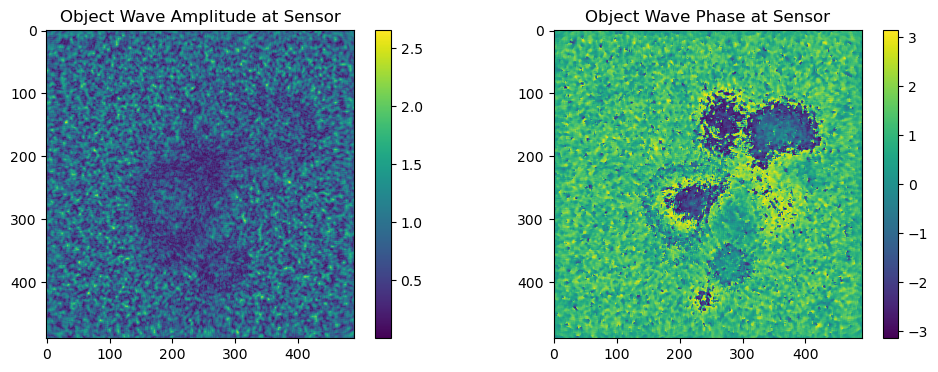

In [13]:
fx, axs = plt.subplots(1, 2, figsize=(12, 4))

im1 = axs[0].imshow(np.abs(obj_wave))
plt.colorbar(im1, ax=axs[0])
axs[0].set_title('Object Wave Amplitude at Sensor')

im2 = axs[1].imshow(np.angle(obj_wave))
plt.colorbar(im2, ax=axs[1])
axs[1].set_title('Object Wave Phase at Sensor')

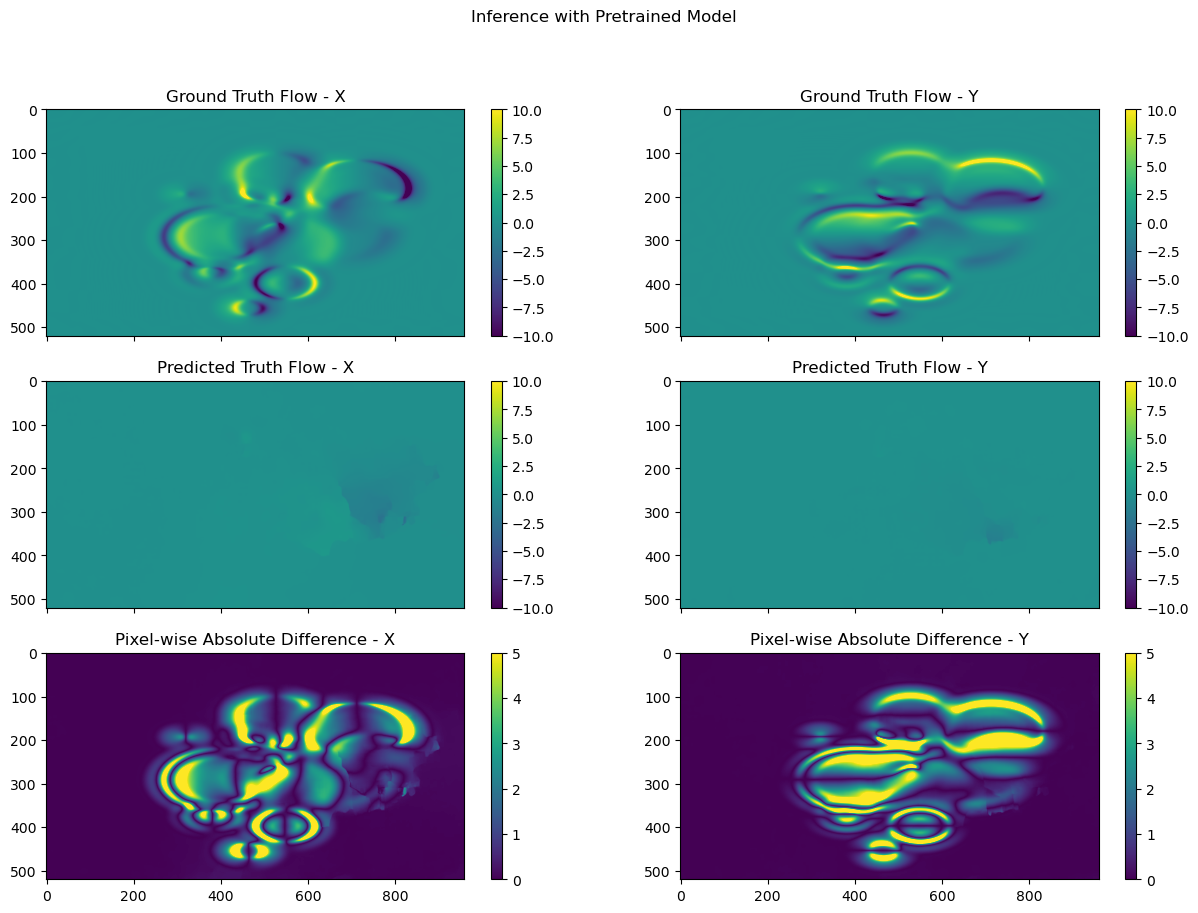

In [14]:
tar = targets[0].detach()
pre = list_of_flows[-1][0].detach()

fx, axs = plt.subplots(3, 2, figsize=(15, 10), sharex=True)

im1 = axs[0, 0].imshow(tar[0], vmin=-10, vmax=10)
plt.colorbar(im1, ax=axs[0, 0])
im2 = axs[0, 1].imshow(tar[1], vmin=-10, vmax=10)
plt.colorbar(im2, ax=axs[0, 1])

axs[0, 0].set_title('Ground Truth Flow - X')
axs[0, 1].set_title('Ground Truth Flow - Y')

im3 = axs[1, 0].imshow(pre[0], vmin=-10, vmax=10)
plt.colorbar(im3, ax=axs[1, 0])
im4 = axs[1, 1].imshow(pre[1], vmin=-10, vmax=10)
plt.colorbar(im4, ax=axs[1, 1])

axs[1, 0].set_title('Predicted Truth Flow - X')
axs[1, 1].set_title('Predicted Truth Flow - Y')

im5 = axs[2, 0].imshow(np.abs(tar[0] - pre[0]), vmin=0, vmax=5)
plt.colorbar(im5, ax=axs[2, 0])
im6 = axs[2, 1].imshow(np.abs(tar[1] - pre[1]), vmin=0, vmax=5)
plt.colorbar(im6, ax=axs[2, 1])

axs[2, 0].set_title('Pixel-wise Absolute Difference - X')
axs[2, 1].set_title('Pixel-wise Absolute Difference - Y')

plt.suptitle('Inference with Pretrained Model')
plt.show()

Loading models with checkpoint: /home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2025_Speckle_Flow_Networks_QIP/coded_wfs_sim/examples/runs/2025-07-05/ckpt/RAFT_synthetic_beads_v4_hblur_RAFT_l1_330.pth


/tmp/ipykernel_111006/2720233514.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(checkpoint, map_location=torch.device(device))


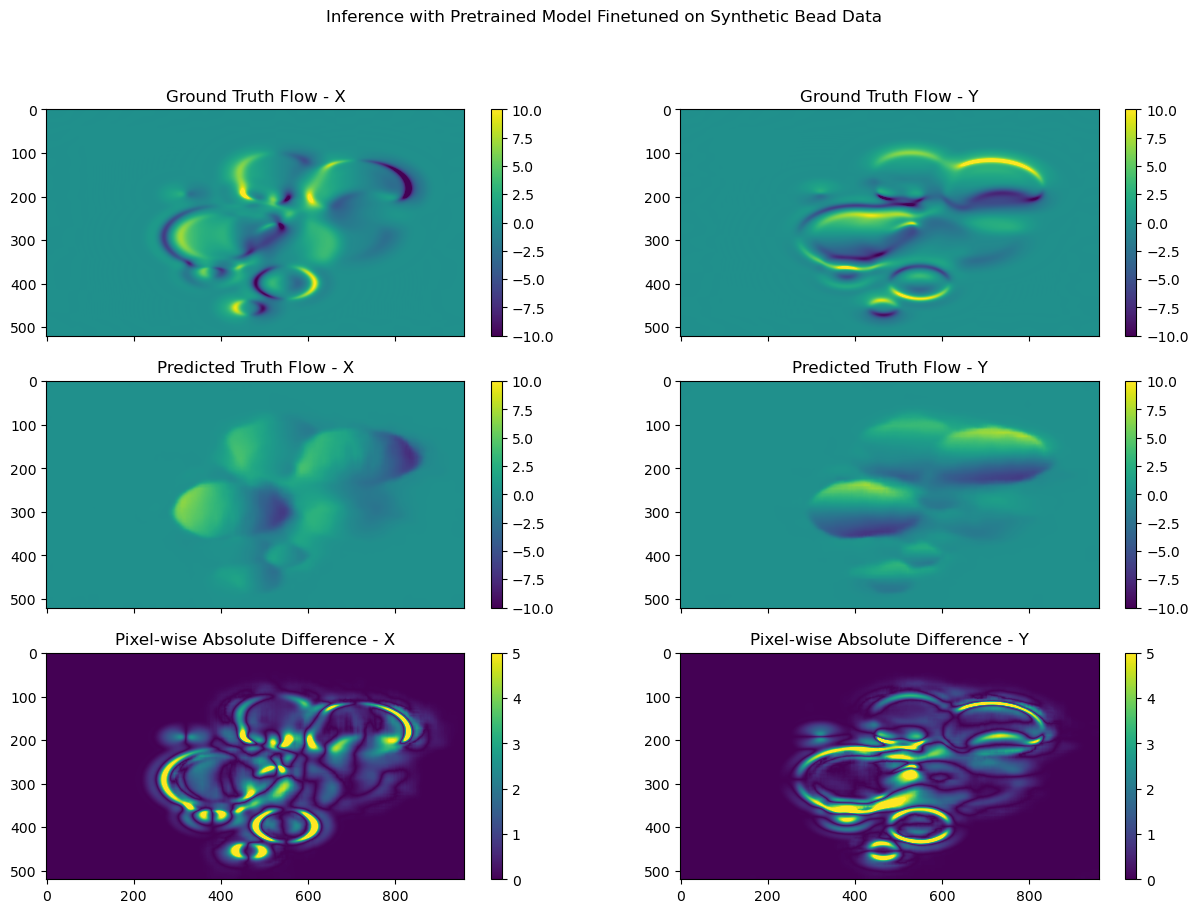

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
ckpt = '/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2025_Speckle_Flow_Networks_QIP/coded_wfs_sim/examples/runs/2025-07-05/ckpt/RAFT_synthetic_beads_v4_hblur_RAFT_l1_330.pth'
model = init_model_RAFT(raft_large(progress=False), device=device, checkpoint=ckpt)


img1_batch, img2_batch = utils.preprocess(ref_imgs, obj_imgs, transforms)
list_of_flows = model(img1_batch.to(device), img2_batch.to(device))

tar = targets[0].detach()
pre = list_of_flows[-1][0].detach()

fx, axs = plt.subplots(3, 2, figsize=(15, 10), sharex=True)

im1 = axs[0, 0].imshow(tar[0], vmin=-10, vmax=10)
plt.colorbar(im1, ax=axs[0, 0])
im2 = axs[0, 1].imshow(tar[1], vmin=-10, vmax=10)
plt.colorbar(im2, ax=axs[0, 1])

axs[0, 0].set_title('Ground Truth Flow - X')
axs[0, 1].set_title('Ground Truth Flow - Y')

im3 = axs[1, 0].imshow(pre[0], vmin=-10, vmax=10)
plt.colorbar(im3, ax=axs[1, 0])
im4 = axs[1, 1].imshow(pre[1], vmin=-10, vmax=10)
plt.colorbar(im4, ax=axs[1, 1])

axs[1, 0].set_title('Predicted Truth Flow - X')
axs[1, 1].set_title('Predicted Truth Flow - Y')

im5 = axs[2, 0].imshow(np.abs(tar[0] - pre[0]), vmin=0, vmax=5)
plt.colorbar(im5, ax=axs[2, 0])
im6 = axs[2, 1].imshow(np.abs(tar[1] - pre[1]), vmin=0, vmax=5)
plt.colorbar(im6, ax=axs[2, 1])

axs[2, 0].set_title('Pixel-wise Absolute Difference - X')
axs[2, 1].set_title('Pixel-wise Absolute Difference - Y')

plt.suptitle('Inference with Pretrained Model Finetuned on Synthetic Bead Data')
plt.show()

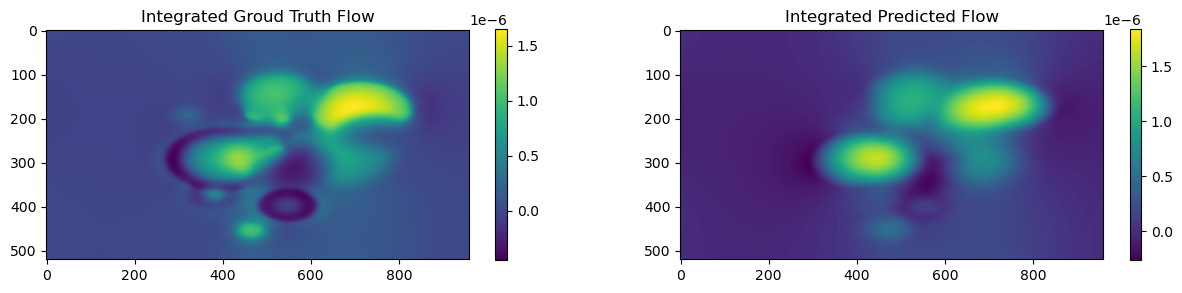

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(15, 3))

tar_OPD = utils.int_2d_fourier([tar[0], tar[1]], 1)*(spatial_resolution[1]*mag)*(dist_m_im + dist_m_im_var)
im1 = axs[0].imshow(tar_OPD - tar_OPD[5, 5])
plt.colorbar(im1, ax=axs[0])
axs[0].set_title('Integrated Groud Truth Flow')

pre_OPD = utils.int_2d_fourier([pre[0], pre[1]], 1)*(spatial_resolution[1]*mag)*(dist_m_im + dist_m_im_var)
im2 = axs[1].imshow(pre_OPD - pre_OPD[5, 5])
plt.colorbar(im2, ax=axs[1])
axs[1].set_title('Integrated Predicted Flow')

plt.show()

# print((gaussian_filter(tar_OPD, 0.1).max() - tar_OPD[-5, -5])/1e-6, (pre_OPD.max() - pre_OPD[-5, -5])/1e-6)

# Draft

1. Conclusion:
    * Predicts (almost finds) bead-like structure at places where it does not exist.
    * Overfitting: data is probably not diverse enough.
    * Works only for beads of a specific size (and probably noise).
2. Outcomes:
    * The network should be able to predict flows accurately of the HEK cell. The bead case is very restrictive.
    * Goal: Deformed HEK cells replicated at different locations.
    * Example cases where the WC-ADMM method does not work but this does:
        1. Create synthetic data for which WC-ADMM works and does not work, but the trained network for both.
        2. Find measured data (bead focal stacks?) for which WC-ADMM is unreliable: wrong estimations and sensitive to parameters.
3. Plan
    * Create synthetic data for which WC-ADMM works and does not work, but the trained network for both.
    * Fit a set of Zernike Polynomials on a sequence of HEK cell video frames (DHM?), find mean and standard deviations of these polynomials and use these distributions to generate wavefields and train the network. Check if the network generalizes to the CWFS recorded cells and its augmentations.

/home/u491036/anaconda3/envs/2025_Optimizing_Phase_Mask/lib/python3.8/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


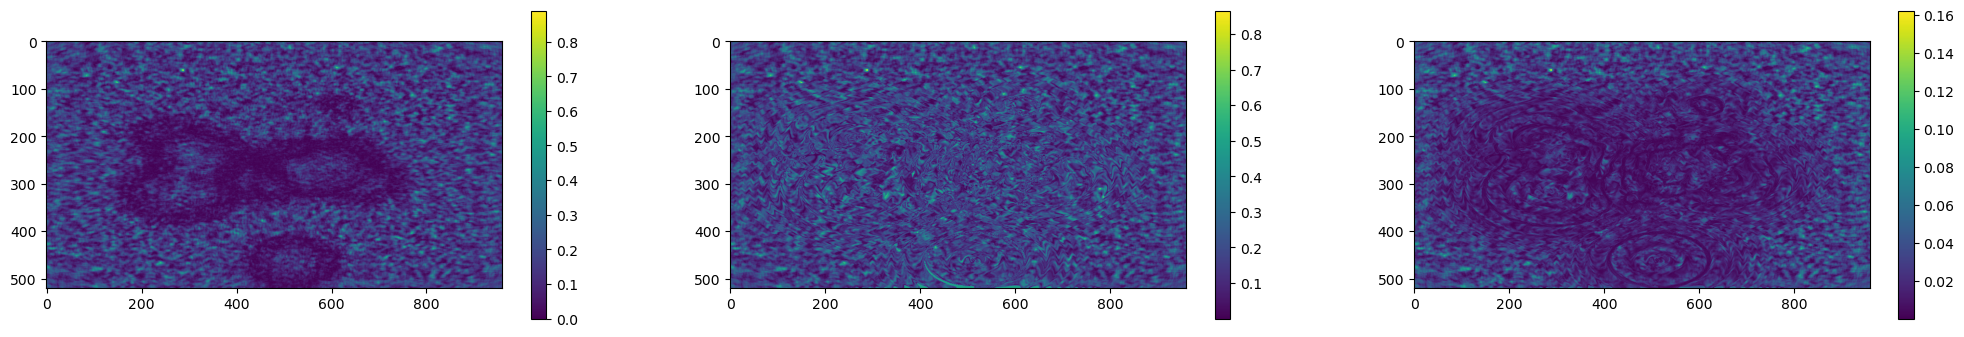

In [57]:
# init grid
x = torch.linspace(-1, 1, I0.shape[0], dtype=torch.float64)
y = torch.linspace(-1, 1, I0.shape[1], dtype=torch.float64)
X_grid, Y_grid = torch.meshgrid((x, y)) # 1d data but grid sample works for 2d

X_grid_warped = X_grid - tar[0, 0]/I0.shape[0]*2
# X_grid_clamped = X_grid_warped.clamp(-1, 1)
Y_grid_warped = Y_grid - tar[0, 1]/I0.shape[1]*2
# Y_grid_clamped = Y_grid_warped.clamp(-1, 1)

grid = torch.stack((Y_grid_warped, X_grid_warped), dim=0).permute(1, 2, 0).unsqueeze(0)  # Shape: (1, N, 1, 2)
I_est = torch.nn.functional.grid_sample(I0.unsqueeze(0).unsqueeze(0).float(), grid.float(), align_corners=True, mode='bilinear').squeeze()

fig, axs = plt.subplots(1, 3, figsize=(25, 4))

im1 = axs[0].imshow((I1+1)/2)
plt.colorbar(im1, ax=axs[0])

im2 = axs[1].imshow(((I_est+1)/2))
plt.colorbar(im2, ax=axs[1])

im3 = axs[2].imshow(((I_est+1)/2)/(gaussian_filter((tar[0][0]**2 + tar[0][1]**2)**0.5, 1) + 5))
plt.colorbar(im3, ax=axs[2])

plt.show()

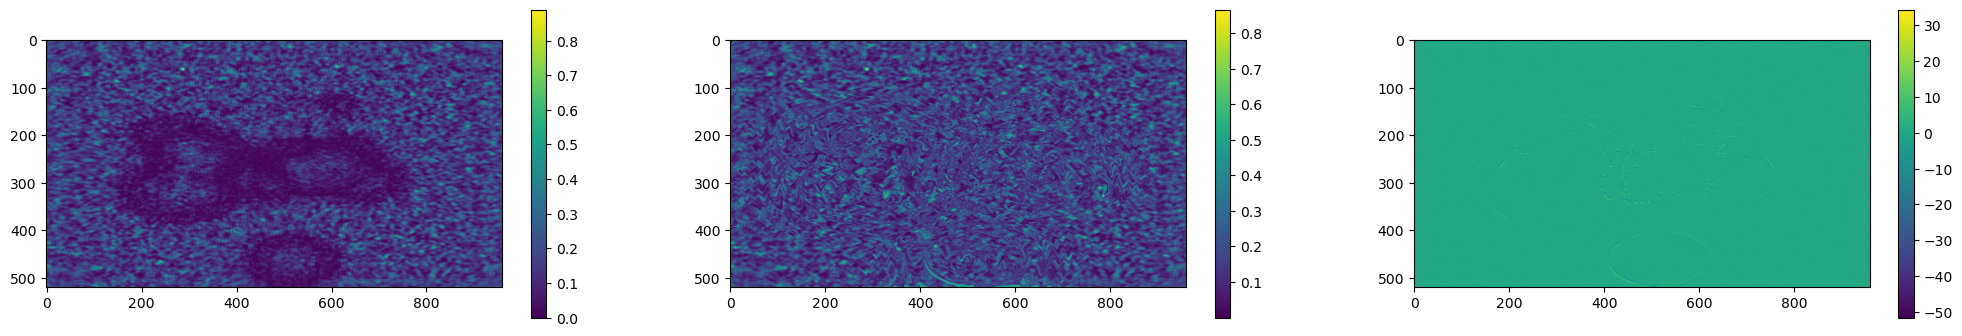

In [59]:
# init grid
x = torch.linspace(-1, 1, I0.shape[0], dtype=torch.float64)
y = torch.linspace(-1, 1, I0.shape[1], dtype=torch.float64)
X_grid, Y_grid = torch.meshgrid((x, y)) # 1d data but grid sample works for 2d

X_grid_warped = X_grid - tar[0, 0]/I0.shape[0]*2
# X_grid_clamped = X_grid_warped.clamp(-1, 1)
Y_grid_warped = Y_grid - tar[0, 1]/I0.shape[1]*2
# Y_grid_clamped = Y_grid_warped.clamp(-1, 1)

grid = torch.stack((Y_grid_warped, X_grid_warped), dim=0).permute(1, 2, 0).unsqueeze(0)  # Shape: (1, N, 1, 2)
I_est = torch.nn.functional.grid_sample(I0.unsqueeze(0).unsqueeze(0).float(), grid.float(), align_corners=True, mode='bilinear').squeeze()

fig, axs = plt.subplots(1, 3, figsize=(25, 4))

im1 = axs[0].imshow((I1+1)/2)
plt.colorbar(im1, ax=axs[0])

im2 = axs[1].imshow(((I_est+1)/2))
plt.colorbar(im2, ax=axs[1])

lap = torch.gradient(tar[0][0], dim=0)[0] + torch.gradient(tar[0][1], dim=1)[0]
im3 = axs[2].imshow(((I_est+1)/2)*(1 + lap))
# torch.softmax(lap)
plt.colorbar(im3, ax=axs[2])

plt.show()



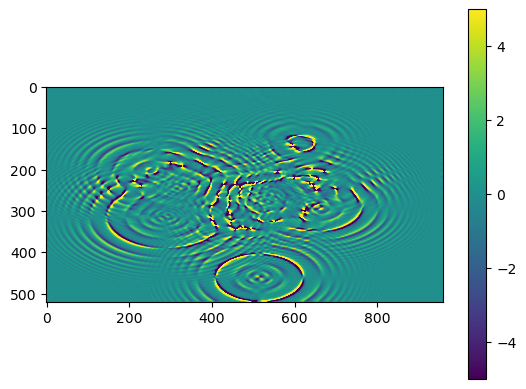

In [60]:
plt.imshow(lap, vmin=-5, vmax=5)
plt.colorbar()

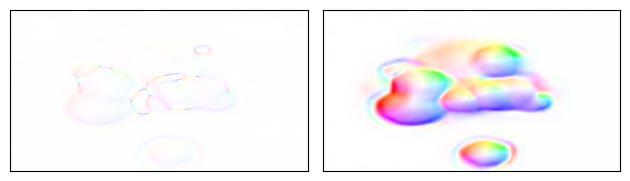

In [61]:
# flow_imgs = flow_to_image(list_of_flows[0])
# flow_targets = flow_to_image(targets.type(torch.float))

flow_imgs = flow_to_image(list_of_flows[-1]).detach()
flow_targets = flow_to_image(targets.type(torch.float)).detach()

grid = [[img1, flow_img] for (img1, flow_img) in zip(flow_targets, flow_imgs)]
plot(grid)
plt.show()